# MLP simples com a diferença


- 1 saida - DeltaTheta
- 2 entradas - Vd e Ve
- 1 camada
- 1 neurônio


In [1]:
import pandas as pd 
import numpy as np
from sklearn.preprocessing import StandardScaler

Datasets = []
PREDICTORS = ["VD", "VE"]
TARGET = ["Theta"]

for i in range(4):   
    Dataset = pd.read_csv(f"../Dados/Data{i + 1}.csv")
    Dataset = Dataset.drop(columns=["X", "Y", "Setpoint VD", "Setpoint VE", "tempo"])
    Dataset.index = (np.arange(0, len(Dataset), 1).astype(float) * 0.07).round(5)
    Datasets.append(Dataset)
    print(f"++++++++++++++++++++ Dataset {i+1} +++++++++++++++++++++++")
    print(Datasets[i].head(5))

++++++++++++++++++++ Dataset 1 +++++++++++++++++++++++
      Theta    VD    VE
0.00    0.0  0.00  0.00
0.07    0.0  2.33  2.33
0.14    0.0  2.33  2.33
0.21    0.0  2.33  2.33
0.28    0.0  2.33  2.33
++++++++++++++++++++ Dataset 2 +++++++++++++++++++++++
      Theta    VD    VE
0.00    0.0  2.33  2.33
0.07    0.0  2.33  2.33
0.14    0.0  2.33  2.33
0.21    0.0  2.33  2.33
0.28   -0.0  2.33  2.33
++++++++++++++++++++ Dataset 3 +++++++++++++++++++++++
      Theta    VD    VE
0.00    0.0  0.00  0.00
0.07    0.0  2.33  2.33
0.14    0.0  2.33  2.33
0.21    0.0  2.33  2.33
0.28    0.0  2.33  2.33
++++++++++++++++++++ Dataset 4 +++++++++++++++++++++++
      Theta    VD    VE
0.00    0.0  2.33  2.33
0.07    0.0  2.33  2.33
0.14    0.0  2.33  2.33
0.21    0.0  2.33  2.33
0.28    0.0  2.33  2.33


In [2]:
for  i in range(4):
    Dataset = Datasets[i].copy()  # evita sobrescrever o original
    Dataset["DeltaTheta"] = Dataset[TARGET].shift(-1) - Dataset[TARGET]
    # ou equivalente: Dataset["DeltaTheta"] = Dataset[TARGET].diff().shift(-1)
    
    # remove o último NaN (último ponto não tem próximo valor)
    Dataset = Dataset.dropna(subset=["DeltaTheta"])
    Datasets[i] = Dataset
    print(f"++++++++++++++++++++ Dataset {i+1} +++++++++++++++++++++++")
    print(Datasets[i].tail(5))


++++++++++++++++++++ Dataset 1 +++++++++++++++++++++++
        Theta    VD    VE  DeltaTheta
149.80  -0.81 -2.20 -2.38        0.00
149.87  -0.81 -2.23 -2.40        0.01
149.94  -0.80 -2.41 -2.24        0.00
150.01  -0.80 -2.40 -2.22        0.00
150.08  -0.80 -2.40 -2.22        0.00
++++++++++++++++++++ Dataset 2 +++++++++++++++++++++++
        Theta    VD    VE  DeltaTheta
141.47   0.73 -2.22 -2.40        0.00
141.54   0.73 -2.23 -2.40        0.00
141.61   0.73 -2.23 -2.40        0.01
141.68   0.74 -2.24 -2.41        0.00
141.75   0.74 -2.41 -2.25        0.00
++++++++++++++++++++ Dataset 3 +++++++++++++++++++++++
       Theta    VD    VE  DeltaTheta
92.40  -0.81 -2.36 -2.18        0.00
92.47  -0.81 -2.37 -2.19        0.00
92.54  -0.81 -2.37 -2.19       -0.01
92.61  -0.82 -2.37 -2.18       -0.01
92.68  -0.83 -2.38 -2.20       -0.01
++++++++++++++++++++ Dataset 4 +++++++++++++++++++++++
        Theta    VD    VE  DeltaTheta
114.17   0.74 -2.09 -2.30        0.00
114.24   0.74 -2.11 -2.31 

In [3]:
NormDatasets = []

TARGET = ["DeltaTheta"]
SCALER = StandardScaler()
OUT_SCALER = StandardScaler()

TrainDataset = Datasets[0]
TrainDataset[PREDICTORS] = SCALER.fit_transform(TrainDataset[PREDICTORS])
TrainDataset[TARGET] = OUT_SCALER.fit_transform(TrainDataset[TARGET])
NormDatasets.append(TrainDataset)

for i in range(3):
      CurrentTestDataset = Datasets[i + 1]
      CurrentTestDataset[PREDICTORS] = SCALER.transform(CurrentTestDataset[PREDICTORS])
      CurrentTestDataset[TARGET] = OUT_SCALER.transform(CurrentTestDataset[TARGET])
      NormDatasets.append(CurrentTestDataset)
      print(f"++++++++++++++++++++ Dataset Normalizado {i+1} +++++++++++++++++++++++")
      print(NormDatasets[i].head(5))

++++++++++++++++++++ Dataset Normalizado 1 +++++++++++++++++++++++
      Theta        VD        VE  DeltaTheta
0.00    0.0  0.098309  0.088927    0.035731
0.07    0.0  1.268315  1.266443    0.035731
0.14    0.0  1.268315  1.266443    0.035731
0.21    0.0  1.268315  1.266443    0.035731
0.28    0.0  1.268315  1.266443    0.035731
++++++++++++++++++++ Dataset Normalizado 2 +++++++++++++++++++++++
      Theta        VD        VE  DeltaTheta
0.00    0.0  1.268315  1.266443    0.035731
0.07    0.0  1.268315  1.266443    0.035731
0.14    0.0  1.268315  1.266443    0.035731
0.21    0.0  1.268315  1.266443    0.035731
0.28   -0.0  1.268315  1.266443    0.035731
++++++++++++++++++++ Dataset Normalizado 3 +++++++++++++++++++++++
      Theta        VD        VE  DeltaTheta
0.00    0.0  0.098309  0.088927    0.035731
0.07    0.0  1.268315  1.266443    0.035731
0.14    0.0  1.268315  1.266443    0.035731
0.21    0.0  1.268315  1.266443    0.035731
0.28    0.0  1.268315  1.266443    0.035731


In [4]:
x_train = np.array(TrainDataset[PREDICTORS])
y_train = np.array(TrainDataset[TARGET])

x_val = np.array((NormDatasets[1])[PREDICTORS])
y_val = np.array((NormDatasets[1])[TARGET])

print(f"Dimensão da entrada: {np.shape(x_train)}")
print(f"Dimensão da saida: {np.shape(y_train)}")

Dimensão da entrada: (2145, 2)
Dimensão da saida: (2145, 1)


In [5]:
import matplotlib.pyplot as plt

def PlotHistory(history):
    plt.figure(figsize=(8, 5))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('MSE Loss')
    plt.title('Training History')
    plt.legend()
    plt.grid(True)
    plt.show()
    
def PlotOut(axs, title, y_true, y_pred):
    y_true = np.ravel(y_true)
    y_pred = np.ravel(y_pred)
    time = (np.arange(0, len(y_pred), 1).astype(float) * 0.07).round(5)

    axs.scatter(time, y_true, marker='o', label='Amostras Reais')
    axs.scatter(time, y_pred, marker='x', label='Valores Preditos')
    axs.set_title(f'{title}')
    axs.set_xlabel('Theta')
    axs.set_ylabel('tempo')
    axs.legend()
    axs.grid(True)

In [6]:
from sklearn.metrics import mean_squared_error, r2_score

TITLES = ["Training", "Validation", "Test 1", "Test 2"]

def EvalModel(model):
    fig, axs = plt.subplots(4, 1, figsize=(12, 12))
    for i, dataset in enumerate(NormDatasets):
        x = np.array(dataset[PREDICTORS])
        
        # diferenças reais e previstas (já desnormalizadas)
        y_diff = OUT_SCALER.inverse_transform(dataset[TARGET])
        y_pred_diff = OUT_SCALER.inverse_transform(model.predict(x))
        
        # valor inicial de theta no dataset original (não normalizado)
        theta0 = Datasets[i]["Theta"].iloc[0]  
        
        # reconstrução: soma cumulativa
        y_real = theta0 + np.cumsum(y_diff, axis=0)
        y_pred = theta0 + np.cumsum(y_pred_diff, axis=0)
        
        # métricas no espaço de θ
        R2 = r2_score(y_real, y_pred)
        MSE = mean_squared_error(y_real, y_pred)
        print(f"R²_{TITLES[i]} = {R2}")
        print(f"MSE_{TITLES[i]} = {MSE}")
        
        # plota saída
        PlotOut(axs[i], TITLES[i], y_real, y_pred)


In [7]:
from tensorflow import keras
from keras.callbacks import EarlyStopping

INPUT_SIZE = len(PREDICTORS)  


model = keras.models.Sequential([
    keras.layers.Input(shape=(INPUT_SIZE,)),
    keras.layers.Dense(1, activation="linear"),  
])
model.summary()
print(f"Pesos inciais:\n {model.get_weights()}")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3 (12.00 B)

 Trainable params: 3 (12.00 B)

 Non-trainable params: 0 (0.00 B)

Pesos inciais:
 [array([[1.3090576 ],
       [0.57695794]], dtype=float32), array([0.], dtype=float32)]


Configures the model for training.

In [8]:
model.compile(loss="mean_squared_error", optimizer="adam")

Trains the model for a fixed number of epochs (dataset iterations).

In [9]:
early_stopping_monitor = EarlyStopping(monitor='val_loss',
                                patience=50,
                                restore_best_weights=True)

history = model.fit(x_train, 
                    y_train, 
                    epochs=1000,
                    callbacks=[early_stopping_monitor],
 validation_data=(x_val, y_val))

Epoch 1/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 4.1376 - val_loss: 4.2196
Epoch 2/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.7840 - val_loss: 3.7506
Epoch 3/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.3927 - val_loss: 3.3338
Epoch 4/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.1908 - val_loss: 2.9607
Epoch 5/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.6030 - val_loss: 2.6323
Epoch 6/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.4600 - val_loss: 2.3497
Epoch 7/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.2712 - val_loss: 2.1024
Epoch 8/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.9688 - val_loss: 1.8934
Epoch 9/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.8215 - val_loss: 1.7089
Epoch 10/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.7309 - val_loss: 1.5530
Epoch 11/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.5452 - val_loss: 1.4205
Epoch 12/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

In [10]:
print(f"Pesos finais:\n {model.get_weights()}")

Pesos finais:
 [array([[ 0.8347593],
       [-0.824264 ]], dtype=float32), array([0.01388143], dtype=float32)]


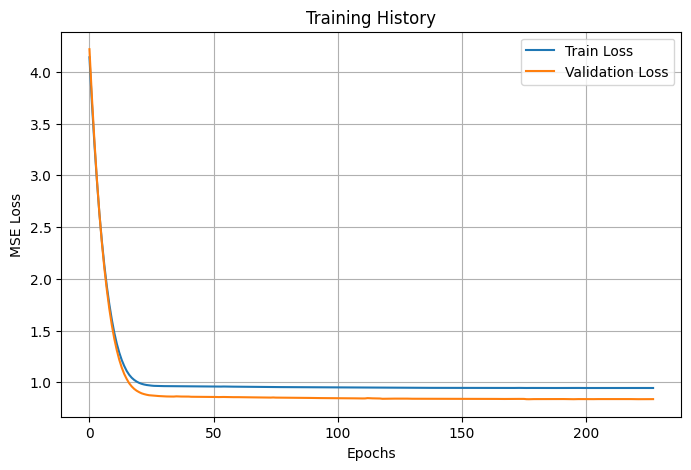

In [11]:
PlotHistory(history)

68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
R²_Training = 0.3646900184262417
MSE_Training = 0.16415868092039293
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
R²_Validation = 0.1390639625054534
MSE_Validation = 0.15266877750515215
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
R²_Test 1 = 0.43275395843859943
MSE_Test 1 = 0.1406209612642226
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
R²_Test 2 = 0.1753493683114954
MSE_Test 2 = 0.14579463507272367


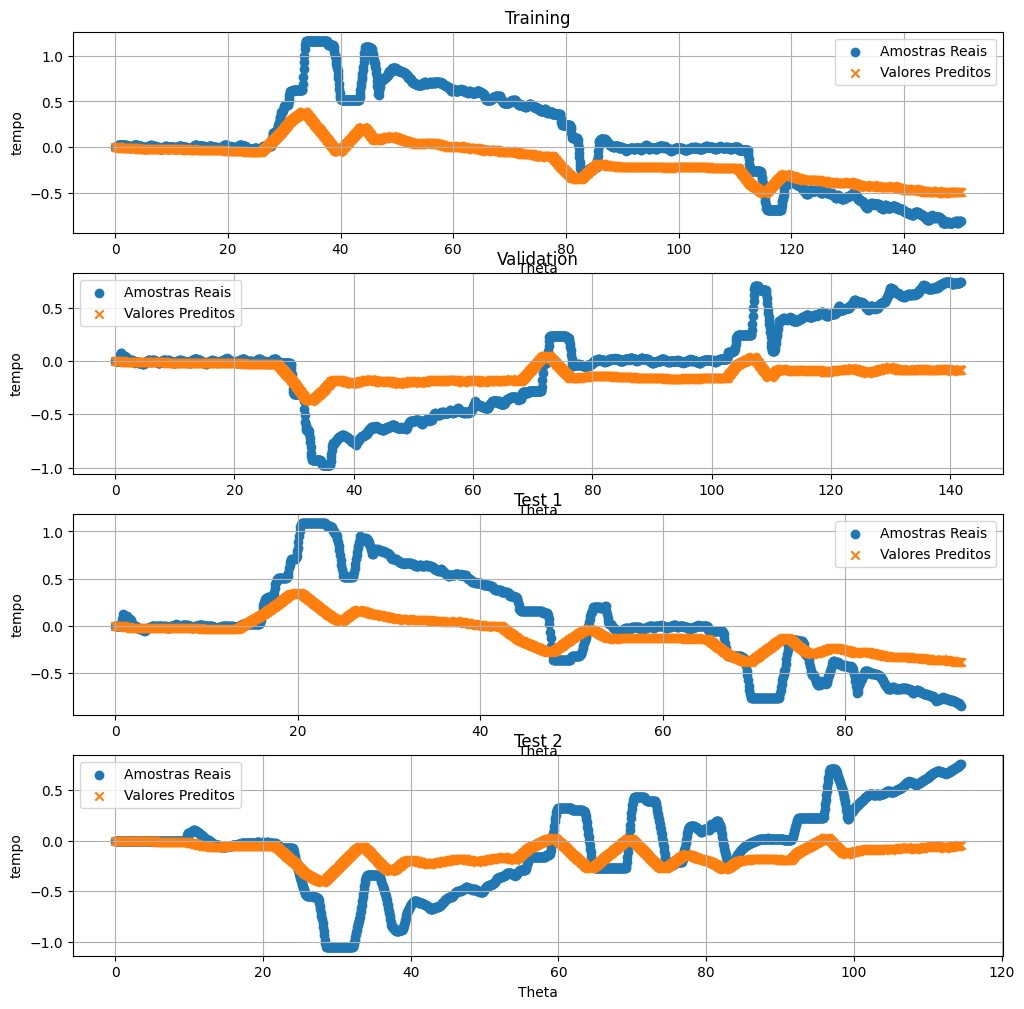

In [12]:
EvalModel(model)